In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



In [13]:
# 1️⃣ Dataset
df = pd.DataFrame({
    'Hours': [5, 3, 6, 2, 4, 7, 1],
    'Attendance': [80, 60, 90, 50, 70, 95, 40],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Study_Level': ['High', 'Low', 'High', 'Medium', 'Medium', 'High', 'Low'],
    'Pass': [1, 0, 1, 0, 1, 1, 0]
})


In [14]:
df

,Hours,Attendance,Gender,Study_Level,Pass
0,5,80,Male,High,1
1,3,60,Female,Low,0
2,6,90,Male,High,1
3,2,50,Female,Medium,0
4,4,70,Male,Medium,1
5,7,95,Female,High,1
6,1,40,Male,Low,0


In [15]:

# Correct ordinal mapping
study_level_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Study_Level'] = df['Study_Level'].map(study_level_mapping)




In [16]:
df

,Hours,Attendance,Gender,Study_Level,Pass
0,5,80,Male,3,1
1,3,60,Female,1,0
2,6,90,Male,3,1
3,2,50,Female,2,0
4,4,70,Male,2,1
5,7,95,Female,3,1
6,1,40,Male,1,0


In [17]:
# 3️⃣ One-hot encode nominal feature
df = pd.get_dummies(df, columns=['Gender'])



In [18]:
# 4️⃣ Features and target
X = df.drop('Pass', axis=1)
y = df['Pass']



In [20]:
X


,Hours,Attendance,Study_Level,Gender_Female,Gender_Male
0,5,80,3,False,True
1,3,60,1,True,False
2,6,90,3,False,True
3,2,50,2,True,False
4,4,70,2,False,True
5,7,95,3,True,False
6,1,40,1,False,True


In [21]:
y

0    1
1    0
2    1
3    0
4    1
5    1
6    0
Name: Pass, dtype: int64

In [22]:
# 5️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)



In [23]:
# 6️⃣ Random Forest
rf = RandomForestClassifier(
    n_estimators=5,       # number of trees
    max_features='sqrt',  # feature sampling at splits
    bootstrap=True,       # row sampling
    random_state=42
)


In [24]:
rf.fit(X_train, y_train)



,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# 7️⃣ Predict & accuracy
y_pred = rf.predict(X_test)
print("Predicted:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))



Predicted: [1 0 1]
Accuracy: 1.0


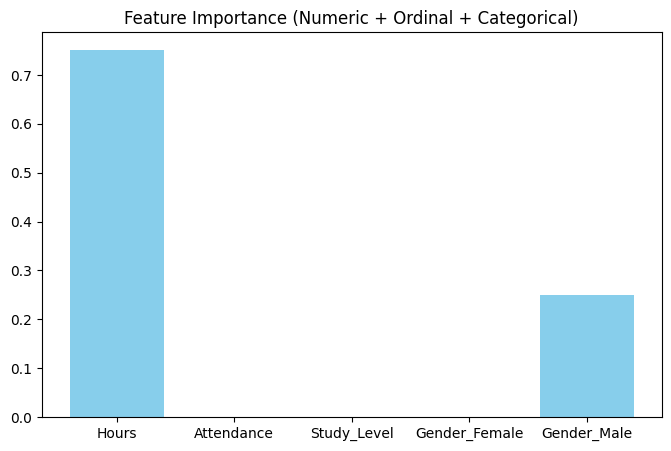

In [26]:
# 8️⃣ Feature importance
importances = rf.feature_importances_
plt.figure(figsize=(8,5))
plt.bar(X.columns, importances, color='skyblue')
plt.title("Feature Importance (Numeric + Ordinal + Categorical)")
plt.show()
